In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<b>1. Регионы с наибольшей аварийностью

Загружаем файл <code>dtp_good.xlsx</code>

In [4]:
data = pd.read_excel('dtp_good.xlsx')

In [5]:
# общая информация
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39085 entries, 0 to 39084
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   reg_code             39085 non-null  int64         
 1   region_name          39085 non-null  object        
 2   road_code            39085 non-null  object        
 3   road_name            39085 non-null  object        
 4   road_type            39085 non-null  object        
 5   address              39085 non-null  object        
 6   crash_type_name      39085 non-null  object        
 7   crash_date           39085 non-null  int64         
 8   crash_time           39085 non-null  object        
 9   crash_reason         39085 non-null  object        
 10  fatalities_amount    39085 non-null  int64         
 11  victims_amount       39085 non-null  int64         
 12  vehicles_amount      39085 non-null  int64         
 13  participants_amount  39085 non-

На этапе предобработки данные были подготовлены для исследования, были добавлены новые столбцы с датой и временем и днем недели.

In [4]:
# размер датасета
data.shape

(39085, 17)

Посмотрим как они распределены по регионам

In [5]:
dtp_count = data['region_name'].value_counts().sort_values(ascending=True)
dtp_count

region_name
Республика Ингушетия                 82
Магаданская область                  82
Ямало-Ненецкий автономный округ      86
Томская область                      89
Севастополь                          90
                                   ... 
Ставропольский край                 956
Республика Башкортостан            1075
Ленинградская область              1425
Краснодарский край                 2294
Московская область                 2764
Name: count, Length: 83, dtype: int64

Визуализируем данные с помощью столбчатой диаграммы и добавим относительные значения

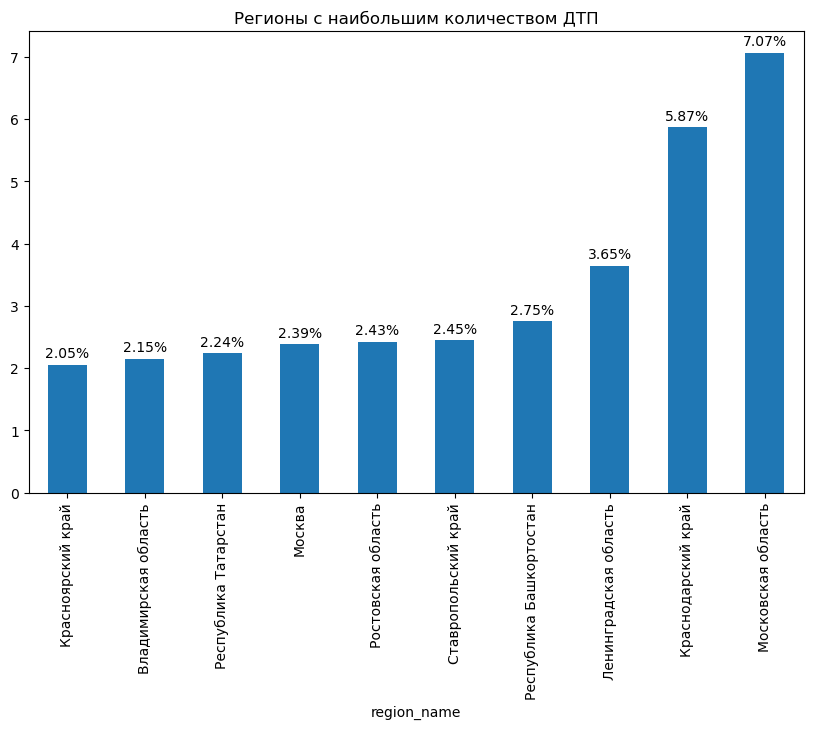

In [6]:
dtp_count = data['region_name'].value_counts().sort_values(ascending=True).reset_index()
dtp_count.columns = ['region_name', 'dtp_count']
dtp_count['perc'] = ((dtp_count['dtp_count'] / dtp_count['dtp_count'].sum())*100).round(4)
ax = dtp_count.tail(10).plot(kind='bar',
                        figsize=(10,6),
                        title='Регионы с наибольшим количеством ДТП',
                        x= 'region_name',
                        y= 'perc',
                        legend=False)
ax.bar_label(ax.containers[0], fmt='%.2f%%',padding=3) #padding-отступ,  fmt # '{:,.2f}'
plt.show()

Ожидаемо было увидеть в лидерах регионы с наибольшим населением - Моосква или Санкт-Петербург. В результате дальнейшего исследования мы возможно найдем причину такого распредления.

<b>2. Распределение числа ДТП по типам дорог, по видам ДТП.

Построим столбчатую диаграмму числа ДТП по типам дорог и диаграмму с 5 самыми частыми видами ДТП.

In [7]:
#создадим датасет числа ДТП по типам дорог
dtp_road = data['road_type'].value_counts().sort_values(ascending=True)
dtp_road.columns = ['road_type', 'dtp_count']
dtp_road

road_type
отсутствует                                                      192
Федеральная дорога общего пользования                          16644
Региональная или межмуниципальная дорога общего пользования    22249
Name: count, dtype: int64

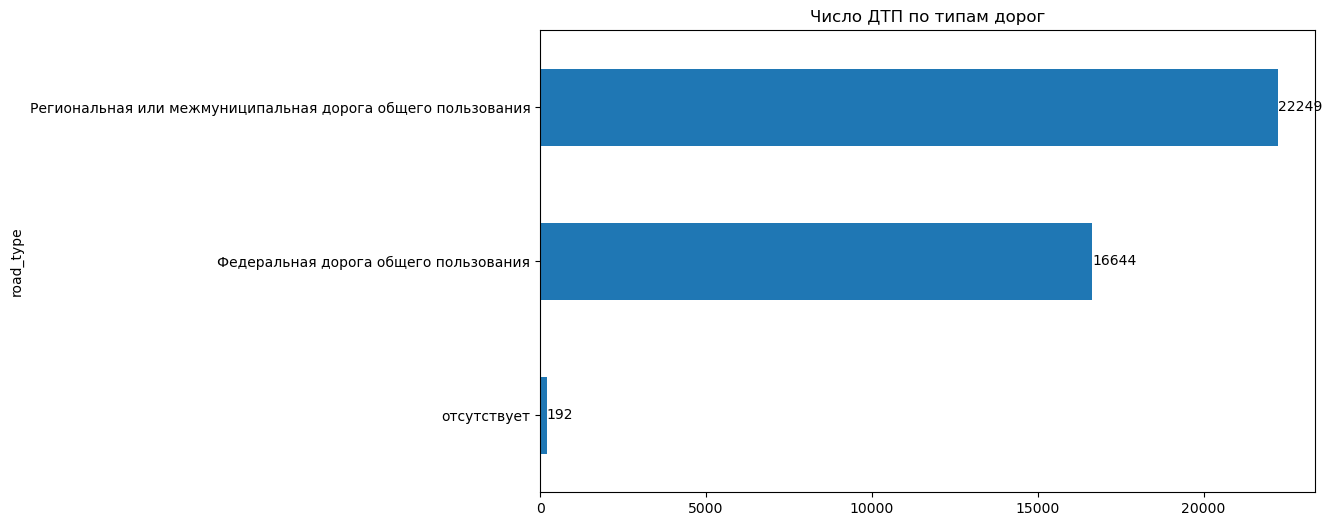

In [8]:
ax = dtp_road.plot(kind = 'barh',
              figsize=(10,6),
              title='Число ДТП по типам дорог',       
              legend=False)
ax.bar_label(ax.containers[0])
plt.show()

In [9]:
#создадим датасет с 5 самыми частами видами ДТП
dtp_type = data['crash_type_name'].value_counts().sort_values(ascending=True)
dtp_type.columns = ['dtp_type, dtp_count']
dtp_type

crash_type_name
Возгорание вследствие технической неисправности движущегося или остановившегося ТС, участвующего в дорожном движении                  1
Наезд на лицо, не являющееся участником дорожного движения(иного участника ДТП), осуществляющее какую-либо другую деятельность        3
Наезд на лицо, не являющееся участником дорожного движения(иного участника ДТП), осуществляющее несение службы                        8
Наезд на внезапно возникшее препятствие                                                                                              11
Наезд на гужевой транспорт                                                                                                           11
Падение груза                                                                                                                        17
Отбрасывание предмета(отсоединение колеса)                                                                                           44
Наезд на лицо, не являющееся уча

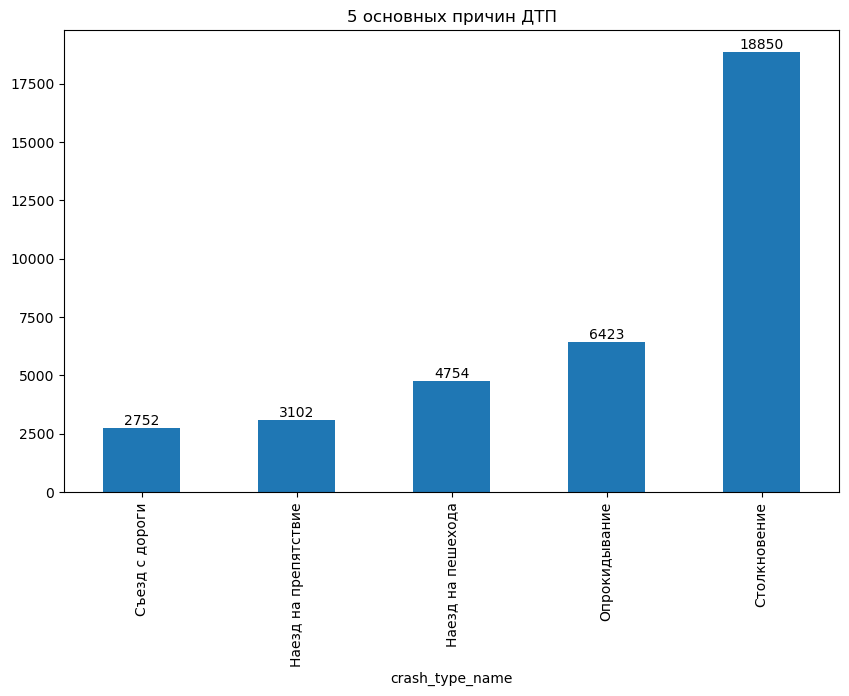

In [10]:
ax = dtp_type.tail(5).plot(kind = 'bar',
              figsize = (10, 6),
              title = '5 основных причин ДТП',
              legend=False)
ax.bar_label(ax.containers[0])
plt.show()

Наиболее популярная причина ДТП - столкновение, они случаются практически в 50% случаев. В три раза меньше случаев с опрокдыванием. Продолжим изучение и поймем причины и закономерность данных случаев.

<b>3. Зависимость числа ДТП от дня недели.

Построим линейный график числа ДТП по дням недели (от понедельника к воскресенью). 

In [11]:
#создадим датасет с сортировокй по дням недели
days = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
data_dtp_day = {'dtp_count':data['crash_date_day'].value_counts()}
dtp_days = pd.DataFrame(data_dtp_day, index = days)
dtp_days

,dtp_count
Понедельник,5269
Вторник,4958
Среда,4886
Четверг,4946
Пятница,5902
Суббота,6602
Воскресенье,6522


<Axes: xlabel='день недели', ylabel='количество ДТП'>

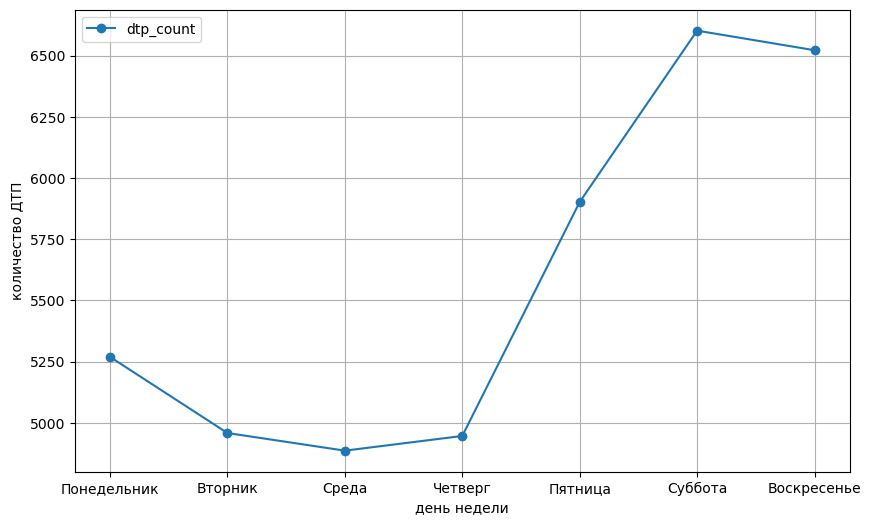

In [12]:
dtp_days.plot(y='dtp_count',
        style='o-',
        grid=True,
        figsize=(10, 6),
        title='',
        ylabel='количество ДТП',
        xlabel='день недели'
       )

Численность ДТП резко увеличиваются к концу недели, чаще всего они происходят в выходные дни, а именно в субботу. Что может быть связано с высокой усталостью, невнимательностью. А также ДТП могут случаться в ночь с пятницы на субботу, что объясняет такой перевес.

<b>4. Регионы с наибольшей аварийностью, числом погибших, пострадавших, участников ДТП.

Определим топ-5 регионов с наибольшим среднем значением числа погибших, числа пострадаших, числа транспортных средств, числа участников. Выведем на экран сводные таблицы и столбчатые диаграммы.

                              fatalities_amount
region_name                                    
Еврейская автономная область           1.298969
Москва                                 1.305466
Московская область                     1.379161
Сахалинская область                    1.380952
Брянская область                       1.409357
                     victims_amount
region_name                        
Санкт-Петербург            0.079545
Москва                     0.094319
Магаданская область        0.097561
Севастополь                0.100000
Республика Алтай           0.125874
                      participants_amount
region_name                              
Москва                           3.457663
Московская область               3.674385
Республика Крым                  3.734973
Севастополь                      3.777778
Чеченская Республика             3.824742
                          vehicles_amount
region_name                              
Республика Тыва                  1

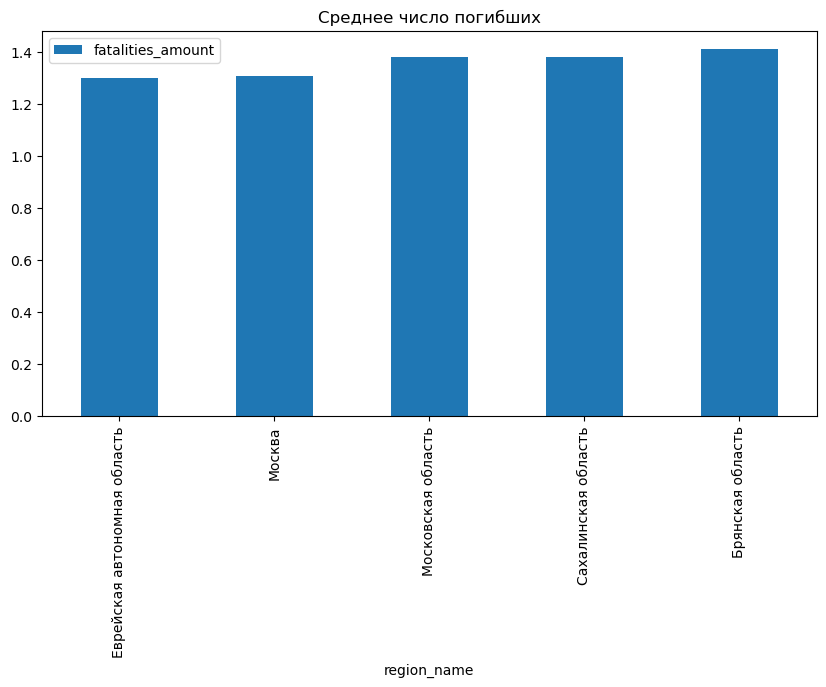

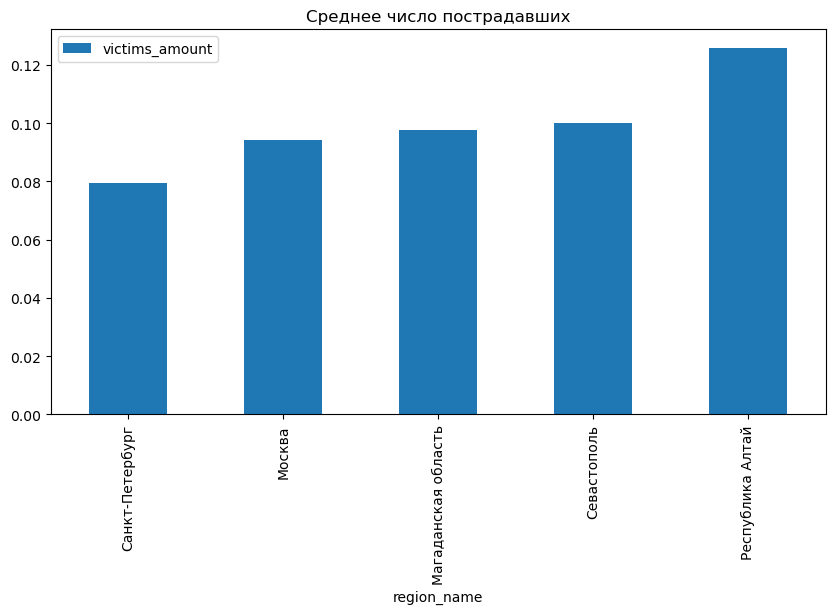

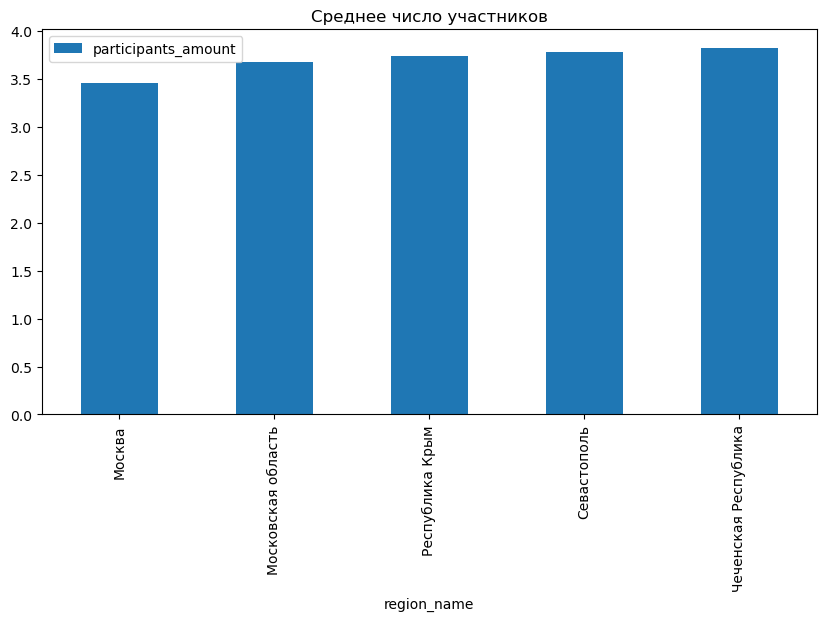

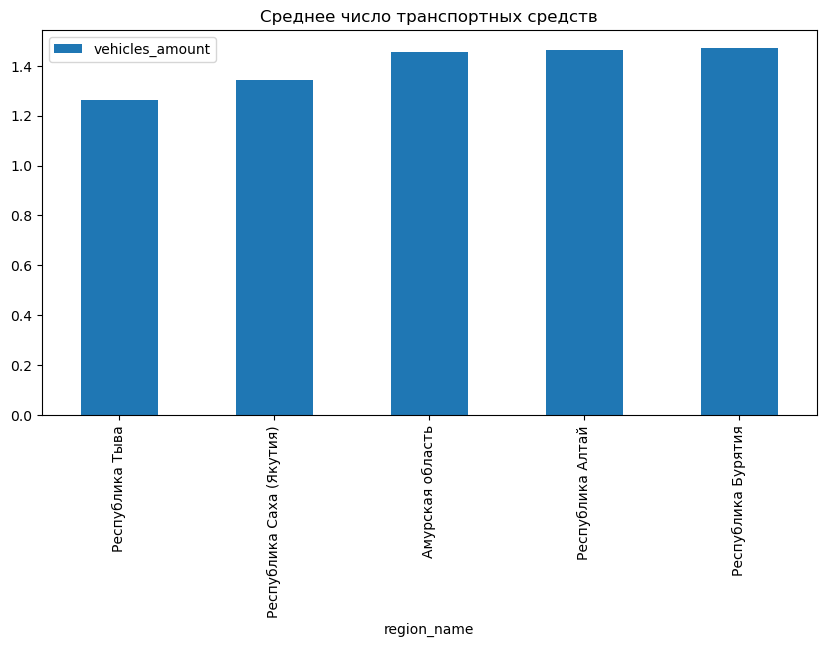

In [13]:
dict = {'fatalities_amount':'Среднее число погибших','victims_amount':'Среднее число пострадавших','participants_amount':'Среднее число участников','vehicles_amount':'Среднее число транспортных средств'}
for key in dict:
    data_pivot_mean = data.pivot_table(index = 'region_name', 
                                       values = key,
                                       aggfunc = 'mean').sort_values(by = key).head(5)
    print(data_pivot_mean)
    data_pivot_mean.plot(kind = 'bar', figsize = (10,5), title = dict[key], legend = True)

 В ДТП в среднем учавсвует 4 участника и 2 тарнспортных средтсва. Среднее число погибших варьируется не сильно и не превышает 1,4 -  можно сделать выывод, что в регионах в каждом ДТП погибает не более двух человек. Пострадавших значительно меньше - 0,12. 

<b> 5. Время ожидания сотрудников ДПС.

Узнаем среднее время ожидания сотрудников ДПС, построим гистограмму.

<Axes: >

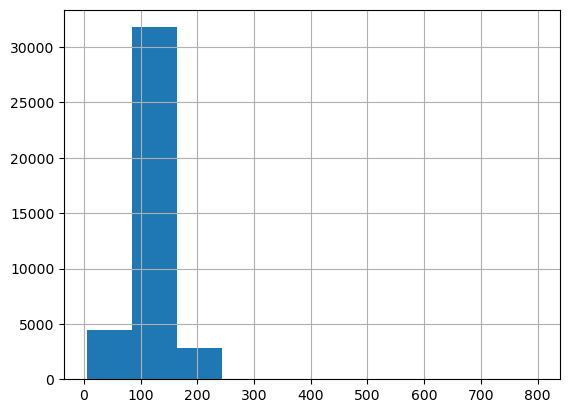

In [14]:
data['wait_time'].hist()

Так как значений с 300 до 800 не так много, ограничим ось х для болььшей детализации

<Axes: >

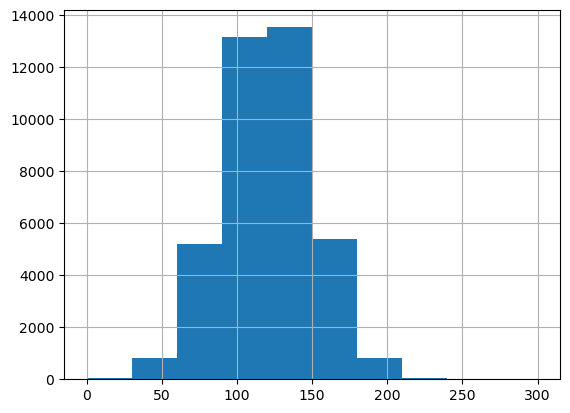

In [15]:
data['wait_time'].hist(range=(0, 300))

Гистограмма похожа на нормальное распределение, теперь это лучше видно.
На первой гистограмме мы видели ось вплоть до 800 значений, но не видели значений, возможно, присутствуют единичные значения  в указанном диапазоне. Построим точечную диаграмму.<br>


<Axes: xlabel='region_name', ylabel='wait_time'>

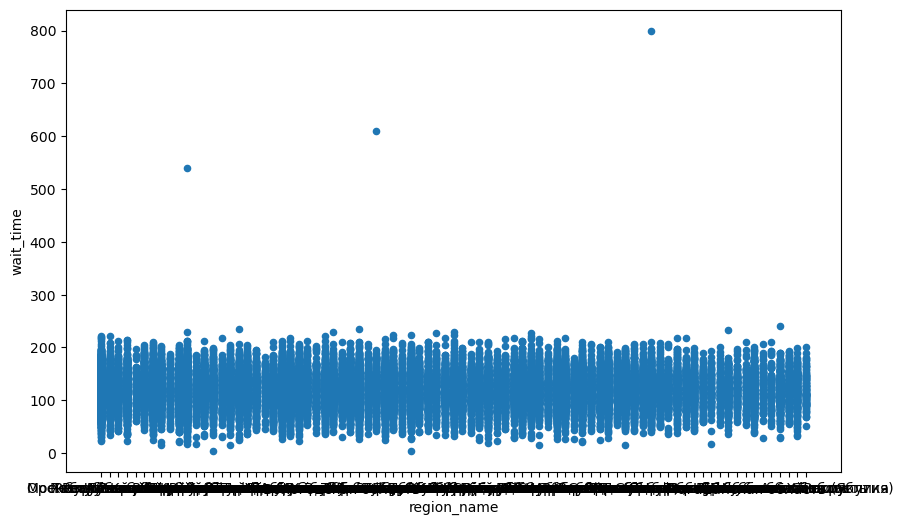

In [16]:
data.plot(kind='scatter', 
          y='wait_time',
          x='region_name',
          figsize=(10, 6))

В основном сотрудники ДПС приезжают в одном промежутке, однако есть единичные случаи с большим значением, которые в дальнейшем могут мешать исследованию. Будем считать их выбросами.

<Axes: >

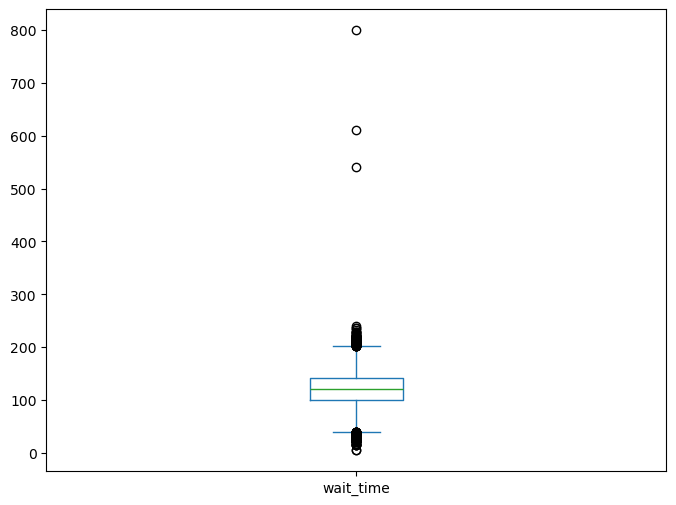

In [17]:
data['wait_time'].plot(kind='box', figsize=(8, 6)) 

В таком масштабе мы видим хвост из выбросов  в диапазоне значений 0-40 и 200-250 и несколько 'экстремальных выбросов' за пределами 500 минут.
Увеличим масштаб для большего понимания.

<Axes: >

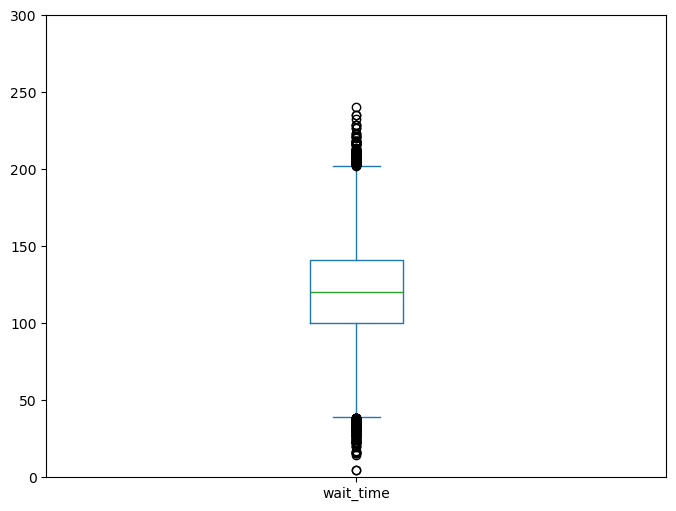

In [18]:
data['wait_time'].plot(kind='box',
                       figsize=(8, 6),
                       ylim=(0, 300)
                      )

На первый взгляд данные симметричны. Из графика можно примерно определить медиану - 125, значение 25го перцентиля - 100, значение 75го перцентиля - 175. Значения за предалми усов не харктерны для данных - их тоже считают выбросами. Узнаем их точные значения.

In [19]:
data['wait_time'].describe()

count    39085.000000
mean       120.405894
std         30.347460
min          4.748831
25%        100.007374
50%        120.524415
75%        140.796472
max        800.000000
Name: wait_time, dtype: float64

Определим число выбросов.

Запишем функцию, которая сообщает предельные значения (длину усов), количество выбросов и их доля в данных

In [20]:
def ejection (col):
    #определим перцентили
    q75 = np.percentile(data[col], 75)
    q25 = np.percentile(data[col], 25)
    #межквартальный размах
    iqr = q75 - q25
    #длина усов
    ejection_h = (q75 + iqr*1.5)
    ejection_l = (q25 - iqr*1.5)
    ejection_count = data[col][(data[col] > ejection_h) | (data[col] < ejection_l)].count()
    ejection_perc = ejection_count/len(data)
    return(ejection_h, ejection_l, ejection_count, ejection_perc)

In [21]:
ejection('wait_time')

(np.float64(201.9801186935365),
 np.float64(38.823726829941734),
 np.int64(259),
 np.float64(0.0066265830881412306))

Создадим новый датасет без выбросов.

In [22]:
good_data_wait_time = data[(data['wait_time'] < ejection('wait_time')[0]) & (data['wait_time'] > ejection('wait_time')[1])]
good_data_wait_time = good_data_wait_time.reset_index(drop=True)
good_data_wait_time.head(3)

,reg_code,region_name,road_code,road_name,road_type,address,crash_type_name,crash_date,crash_time,crash_reason,fatalities_amount,victims_amount,vehicles_amount,participants_amount,datetime,crash_date_day,wait_time
0,46,Московская область,отсутствует,мкр. Авиационный-Лямцино-ММК,Региональная или межмуниципальная дорога общег...,"ЦФО, Московская область, Городской округ Домод...",Опрокидывание,20181231,23:55:00,Другие нарушения ПДД водителями,1,0,1,12,2018-12-31 23:55:00,Понедельник,143.807252
1,53,Оренбургская область,53К-2118000,Обход г. Оренбурга,Региональная или межмуниципальная дорога общег...,"ПФО, Оренбургская область, Оренбург",Наезд на препятствие,20181231,23:55:00,Другие нарушения ПДД водителями,1,0,1,2,2018-12-31 23:55:00,Понедельник,148.198679
2,46,Московская область,А-107,"""Московское малое кольцо"" Икша - Ногинск - Бро...",Федеральная дорога общего пользования,"ЦФО, Московская область, Дмитровский район",Опрокидывание,20181231,23:40:00,Превышение установленной скорости движения,1,0,1,2,2018-12-31 23:40:00,Понедельник,71.441987


<Axes: >

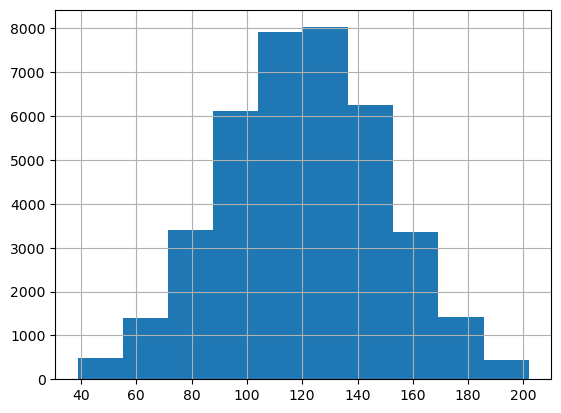

In [23]:
good_data_wait_time['wait_time'].hist()

Распределение еще больше приблизилось к нормальному.

In [24]:
good_data_wait_time['wait_time'].describe()

count    38826.000000
mean       120.379495
std         29.160773
min         38.858157
25%        100.174698
50%        120.526717
75%        140.621013
max        201.878534
Name: wait_time, dtype: float64

<Axes: >

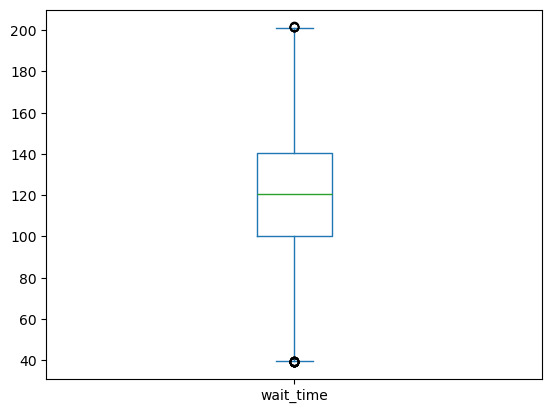

In [25]:
good_data_wait_time['wait_time'].plot(kind='box') 

Теперь данные распределены равномерно.

<Axes: xlabel='region_name', ylabel='wait_time'>

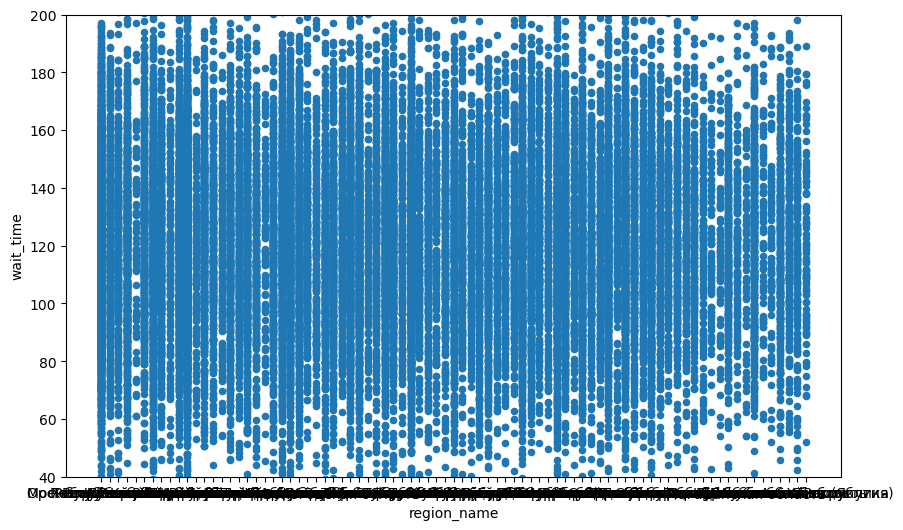

In [26]:
good_data_wait_time.plot(kind='scatter',
          y='wait_time',
          x='region_name',
          figsize=(10, 6),
            ylim = (40, 200))

Выбросы по признаку времени ожидания устранены. Данные готовы для проведения статистического анализа и/или построения модели прогноза времени ожидания сотрудников ДПС.

Определим регионы с максимальным отклонением среднего времени ожидания от среднего времени ожидания по стране.

In [27]:
#построим сводную таблицу
sko_wait_time = good_data_wait_time.pivot_table(index = 'region_name',
                           values = 'wait_time',
                           aggfunc = lambda x: (x.mean() - good_data_wait_time['wait_time'].mean())).sort_values(by = 'wait_time', ascending=False)
sko_wait_time

,wait_time
region_name,
Республика Марий Эл,3.667900
Калининградская область,3.360278
Ульяновская область,2.994815
Алтайский край,2.900547
Санкт-Петербург,2.854031
...,...
Смоленская область,-2.268936
Архангельская область,-2.986150
Ярославская область,-3.184884


Среднее ожидание в Республике Марий Эл превышает среднее ожидание по стране на 3,67 минут, в то время как в Республике Тыва наооборот сотрудники ДПС приехжают на 3,57 минуты быстрее. Региона, в котором ожидание значительно отклоняется от среднего, не найден. 

Посмотрим гистограмму среднего отклонение.

<Axes: >

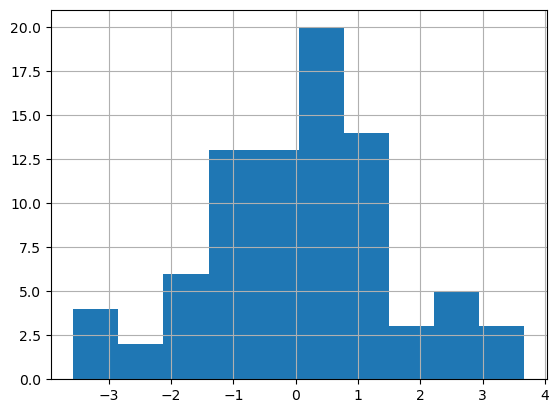

In [28]:
sko_wait_time['wait_time'].hist()

Распределение чем-то напоминает нормальное.

array([<Axes: title={'center': 'wait_time'}, xlabel='region_name'>],
      dtype=object)

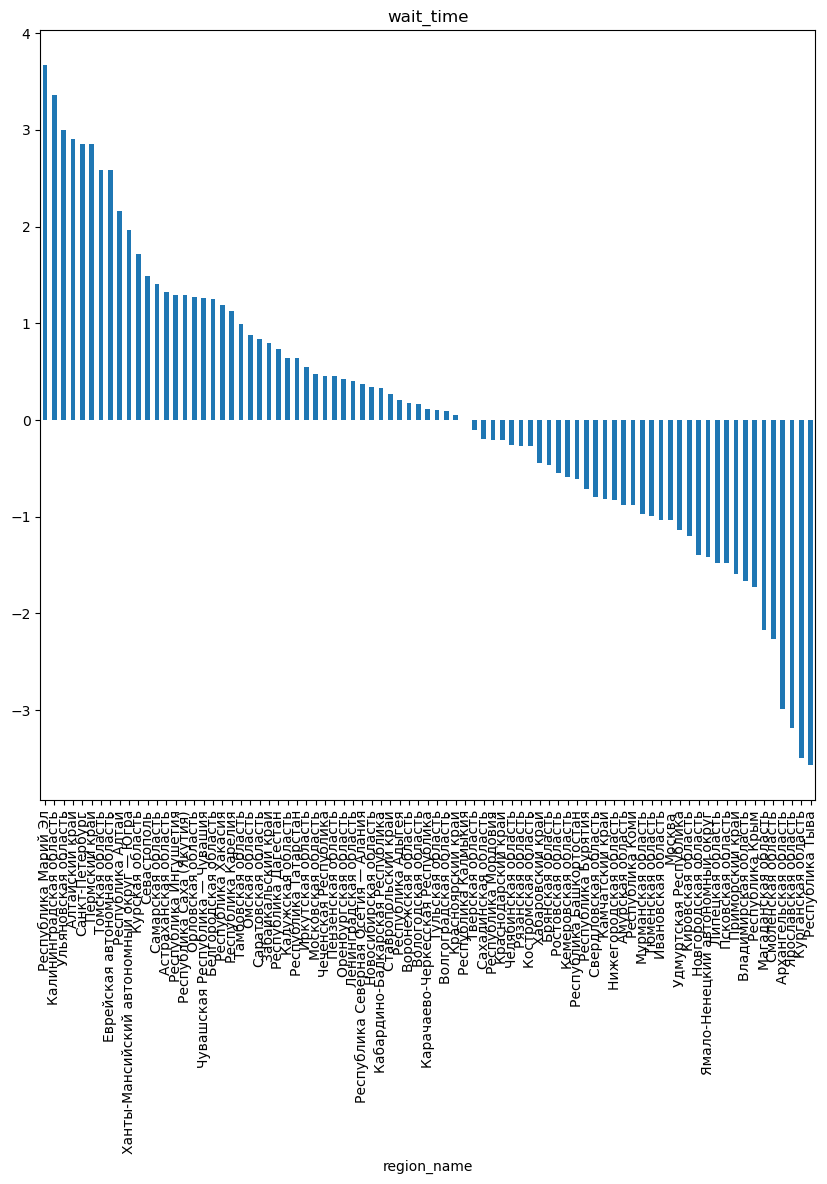

In [29]:
sko_wait_time['wait_time'].plot(kind = 'bar',
                subplots = True,
                legend = False,
                figsize = (10, 10))

<b> 6. Число участников ДТП

<Axes: >

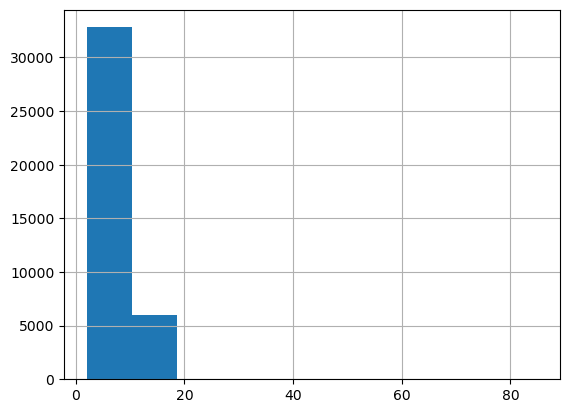

In [30]:
# построим гистограмму 'participants_amount'
good_data_wait_time['participants_amount'].hist()

Количество пострадавших в большинстве своем принимает значение от 0 до 10, количество пострадваших более 10 происодят реже.

Добавим границы для более точной визуализации

<Axes: >

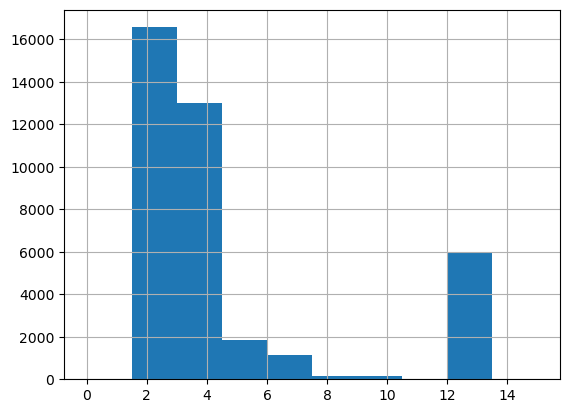

In [31]:
good_data_wait_time['participants_amount'].hist(range = (0, 15))

Массовые ДТП случаются в 5 раз реже, чем столкновение 2 участников. Однако нас также может заинтересовать большое значение ДТП с количеством участников 12, это может быть вызвано некорректной записью данных сотрудников ДПС.

Построим точечную диаграмму.

<Axes: xlabel='region_name', ylabel='participants_amount'>

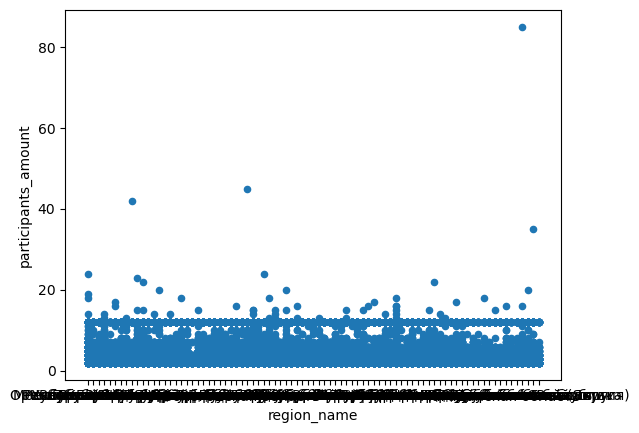

In [32]:
good_data_wait_time.plot(kind='scatter',
                         x = 'region_name',
                        y = 'participants_amount')

В основном количество пострадаших не сильно отличается, но есть и экстримальные значения. Зададим границы.

<Axes: xlabel='region_name', ylabel='participants_amount'>

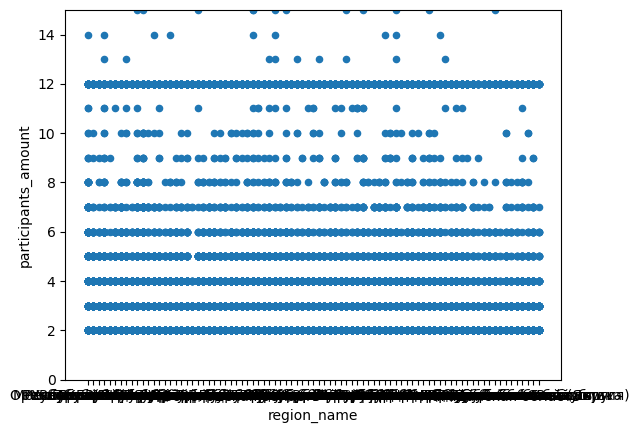

In [33]:
good_data_wait_time.plot(kind='scatter',
                         x = 'region_name',
                        y = 'participants_amount',
                        ylim = (0, 15))

<Axes: >

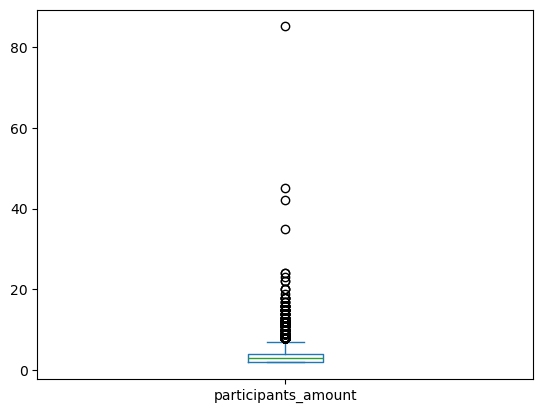

In [34]:
good_data_wait_time['participants_amount'].plot(kind='box')

Скорректируем ось у.

<Axes: >

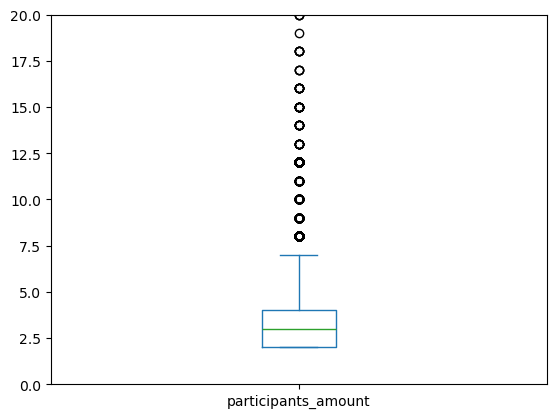

In [35]:
good_data_wait_time['participants_amount'].plot(kind='box', ylim = (0, 20))

Можно сделать выводы, о медиане ~ 3, 25-й перцентиль ~ 2, 75-й ~ 4, межквартальный интервал ~ 2, выбросами можно считать значения больше 7,5. Также замечаем странность - нет нижнего уса. Отсутствие нижнего уса связано с отсутвием значений меньших Q1 - 1.5 * IQR

Воспользуемся прошлой функцией и найдем тчоные длины усов, количество выбросов и их долю.

In [36]:
data['participants_amount'].describe()

count    39085.000000
mean         4.316259
std          3.537298
min          2.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         85.000000
Name: participants_amount, dtype: float64

In [37]:
ejection('participants_amount')

(np.float64(7.0),
 np.float64(-1.0),
 np.int64(6359),
 np.float64(0.16269668670845594))

Видим парадоксальное значение - 6359 выбросов. Удаление данных может значительно испортить анализ и дальнешее исследование, поэтому найдем число выбросов при более высоком значение перцентиля. 
Знчаение -1 также связано с отсутвием значений меньших Q1 - 1.5 * IQR.


In [38]:
q95 = np.percentile(data['participants_amount'], 95)
q25 = np.percentile(data['participants_amount'], 25)
iqr2 = q95 - q25
participants_amount_ejection_h = q95 + iqr2*1.5
participants_amount_ejection_l = q25 - iqr2*1.5

In [39]:
participants_amount_count = good_data_wait_time['participants_amount'][(good_data_wait_time['participants_amount'] > participants_amount_ejection_h) | 
(good_data_wait_time['participants_amount'] < participants_amount_ejection_l)].count()

In [40]:
participants_amount_ejection_perc = participants_amount_count/len(data)


Почему значения в таком объеме равны 12, в то время как соседние значения 11 и 13 представлены единичными случаями? Удалим "экстримальные выбросы" и попытаемся ответить на вопрос.

In [41]:
#убираем выбросы
good_data_participants = good_data_wait_time[(good_data_wait_time['participants_amount'] < participants_amount_ejection_h) &
(good_data_wait_time['participants_amount'] > participants_amount_ejection_l)].reset_index(drop=True)
good_data_participants.head(3)

,reg_code,region_name,road_code,road_name,road_type,address,crash_type_name,crash_date,crash_time,crash_reason,fatalities_amount,victims_amount,vehicles_amount,participants_amount,datetime,crash_date_day,wait_time
0,46,Московская область,отсутствует,мкр. Авиационный-Лямцино-ММК,Региональная или межмуниципальная дорога общег...,"ЦФО, Московская область, Городской округ Домод...",Опрокидывание,20181231,23:55:00,Другие нарушения ПДД водителями,1,0,1,12,2018-12-31 23:55:00,Понедельник,143.807252
1,53,Оренбургская область,53К-2118000,Обход г. Оренбурга,Региональная или межмуниципальная дорога общег...,"ПФО, Оренбургская область, Оренбург",Наезд на препятствие,20181231,23:55:00,Другие нарушения ПДД водителями,1,0,1,2,2018-12-31 23:55:00,Понедельник,148.198679
2,46,Московская область,А-107,"""Московское малое кольцо"" Икша - Ногинск - Бро...",Федеральная дорога общего пользования,"ЦФО, Московская область, Дмитровский район",Опрокидывание,20181231,23:40:00,Превышение установленной скорости движения,1,0,1,2,2018-12-31 23:40:00,Понедельник,71.441987


<Axes: >

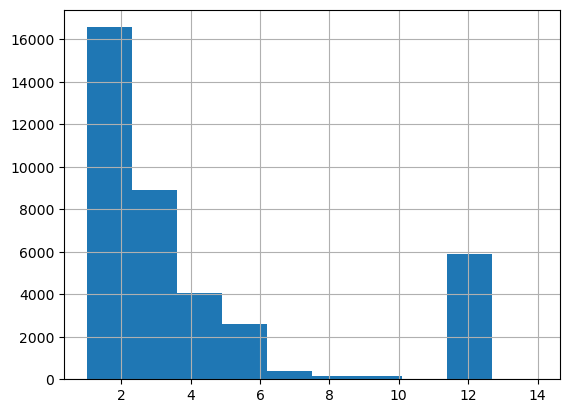

In [42]:
good_data_participants['participants_amount'].hist(range = (1,14))

In [43]:
data[data['participants_amount'] == 12]['crash_type_name'].value_counts()

crash_type_name
Опрокидывание                                                                                                                     2980
Наезд на препятствие                                                                                                              1503
Съезд с дороги                                                                                                                    1221
Наезд на животное                                                                                                                  156
Наезд на стоящее ТС                                                                                                                 45
Иной вид ДТП                                                                                                                        29
Столкновение                                                                                                                        17
Наезд на внезапно возникшее препятствие

In [44]:
data[data['participants_amount'] == 12]['vehicles_amount'].value_counts()

vehicles_amount
1     5625
2      311
3       17
4        4
6        3
7        2
10       1
Name: count, dtype: int64

Значение участников 12 не слуйчайно. В большинстве своем в аварию попадает одно транспортное средство, а причиной становится опрокидывание, наезд на препятствие, съезд с дороги. Видимо в аврию попадает пассажирский транспорт - микроавтобусы, автобусы. Число пострадавших записывается по числу мест, однако дигармма определяет такие значения как выбросы. Удаление данных приведет к неточсти дальнейшего исследования, поэтому понимание, откуда они берутся очень важно.

Проведем анализ для столбцов 'fatalities_amount','vehicles_amount','victims_amount' 

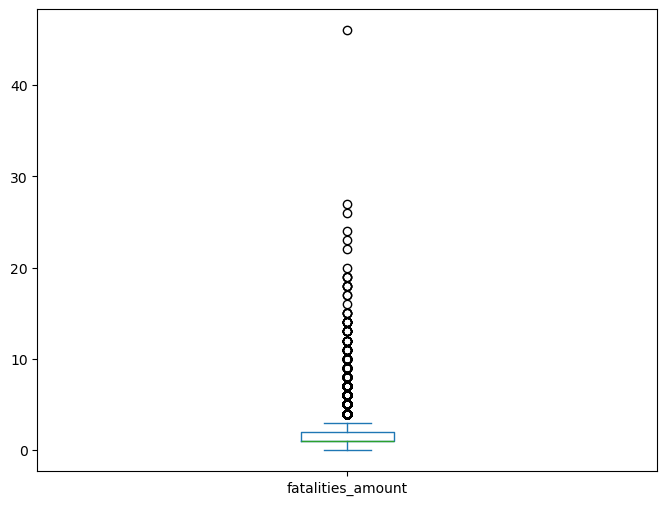

Значение столбца fatalities_amount при percentile равным 99.9  - 13.0
Число выбросов для столбца fatalities_amount  - 31
Процент выбросов: 0.0007931431495458615


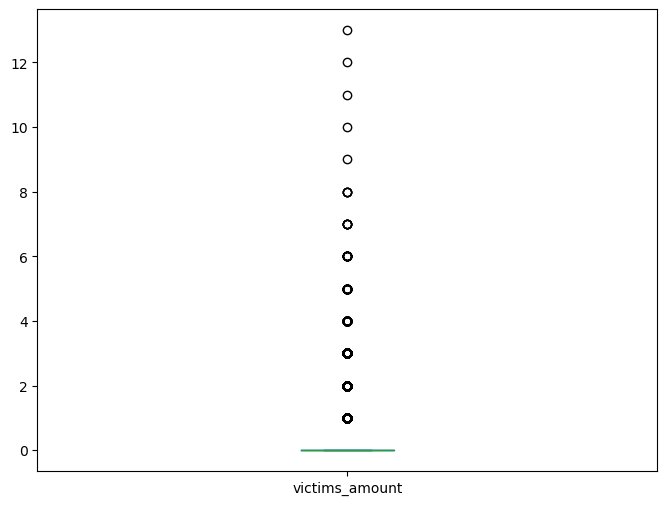

Значение столбца victims_amount при percentile равным 99.9  - 5.0
Число выбросов для столбца victims_amount  - 35
Процент выбросов: 0.0008954842011001664


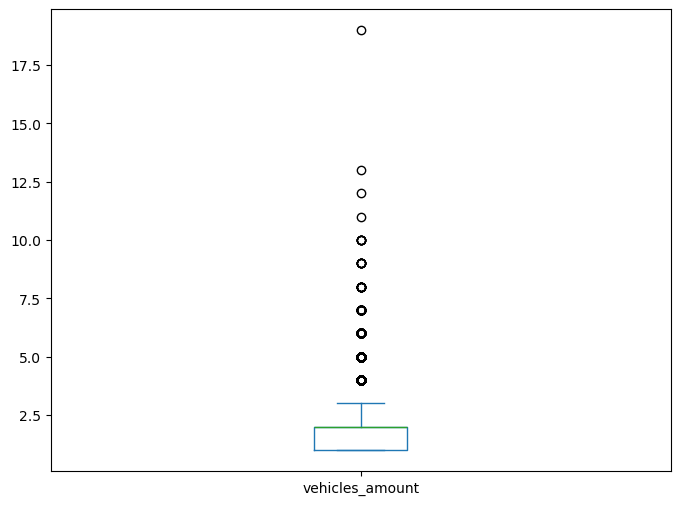

Значение столбца vehicles_amount при percentile равным 99.9  - 7.0
Число выбросов для столбца vehicles_amount  - 32
Процент выбросов: 0.0008187284124344377


In [7]:
col_list = ['fatalities_amount', 'victims_amount', 'vehicles_amount']
for col in col_list:
    data[col].plot(kind = 'box', figsize = (8,6))
    plt.show()
    eject = np.percentile(data[col], 99.9)
    print('Значение столбца', col, 'при percentile равным 99.9', ' -', eject)
    eject_count = data[col][data[col] > eject].count()
    print('Число выбросов для столбца', col, ' -', eject_count)
    print('Процент выбросов:', format(eject_count/len(data)))

99.9% всех наблюдений в вашем наборе данных имеют число погибших меньше или равное 13, при этом число жертв - 5, а транспортные средства - 7. 
Dыбросами были признаны все значения, которые превышают данные пороги. Таких записей в данных нашлось 31, 35, 32.
Процент выбросоов для трех столбоцв составил - 0,079%; 0,090%; 0,082%.

In [16]:
data[data['victims_amount'] > 5]['crash_type_name'].value_counts()

crash_type_name
Столкновение           34
Наезд на стоящее ТС     1
Name: count, dtype: int64

In [17]:
data[data['victims_amount'] > 5]['vehicles_amount'].value_counts()

vehicles_amount
2    22
3    10
5     1
6     1
4     1
Name: count, dtype: int64

Число выбросов количества пострадавших случаются из-за столкновений 2-3 транспортынх средств. Как и в прошлом пункте можно предположить, что в аврию попадает пассажирский транспорт, а также семьи с детьми. Удаление выбросов приведет к ошибкам в дальнейших расчётах.

In [19]:
data[data['vehicles_amount'] > 7]['crash_type_name'].value_counts()

crash_type_name
Столкновение           25
Наезд на стоящее ТС     7
Name: count, dtype: int64

<b> 7. Топ-10 дорог пересекающих разные регионы по количеству участников ДТП.

In [45]:
road_region = data.query('not road_code == "отсутствует"').pivot_table(index = 'road_code',
                 values = ['crash_type_name', 'region_name', 'fatalities_amount', 'participants_amount'],
                 aggfunc = {'crash_type_name':'count','region_name' : 'nunique', 'fatalities_amount' : 'sum', 'participants_amount' : 'sum'}).sort_values(by = 'region_name', ascending = False).reset_index().head(10)
road_region

,road_code,crash_type_name,fatalities_amount,participants_amount,region_name
0,М-5,1186,1922,4744,11
1,М-7,1277,1933,4818,9
2,Р-217,943,1614,3860,9
3,Р-22,477,839,2068,9
4,М-4,1035,1629,4018,7
5,М-2,492,773,1875,6
6,М-8,463,753,1891,6
7,Р-254,298,468,1188,5
8,Р-255,598,918,2409,5
9,М-10,514,671,1936,5


Дорога М-5 проходит через 11 субъектов РФ, что является максимальным показателем. Длина дороги и прохождение через множество населенных пунктов и областей с разными условиями объясняет высокое число ДТП и жертв.

Самая аварийная дорога — М-7. На трассе М-7 ("Волга") зафиксировано наибольшее количество ДТП (1277). При этом по числу погибших она также на первом месте (1933 человека). Это указывает на высокую интенсивность движения и, возможно, на сложные дорожные условия на этом направлении.

Разрыв в количестве погибших между М-7 (1933) и М-5 (1922) очень мал. Это означает, что аварии на М-5 "Урал" в среднем более тяжелые.

Трассы с высокой аварийностью при меньшем охвате:

Трасса М-4 "Дон" проходит всего через 7 регионов, но имеет третье место по количеству ДТП (1035) и погибших (1629). Это одна из самых загруженных трасс России, соединяющая Москву с югом, что объясняет статистику.

Таблица наглядно демонстрирует, что трассы М-7 "Волга" и М-5 "Урал" являются наиболее опасными в России по абсолютному числу ДТП и погибших. Высокие показатели также у трасс М-4 "Дон" и Р-217 "Кавказ". Данные свидетельствуют о необходимости повышенного внимания к мерам безопасности (качество покрытия, освещение, ограждения, контроль скорости) именно на этих направлениях.

<b> 8. Число ДТП  для определенных ранее дорог по регионам.

In [46]:
code = road_region['road_code'].unique().tolist()
road_region_data = data.query('not road_code == "отсутствует" and road_code in @code').pivot_table(index = ['region_name', 'road_code'],
                                                                             values = ['crash_type_name', 'fatalities_amount', 'participants_amount'],
                                                                             aggfunc = {'crash_type_name': 'count','fatalities_amount' : 'sum', 'participants_amount' : 'sum'}).sort_values(by = 'crash_type_name', ascending = False).reset_index()
road_region_data

,region_name,road_code,crash_type_name,fatalities_amount,participants_amount
0,Владимирская область,М-7,380,563,1435
1,Республика Дагестан,Р-217,300,561,1132
2,Краснодарский край,М-4,282,455,1105
3,Ставропольский край,Р-217,234,383,1020
4,Ярославская область,М-8,228,390,885
...,...,...,...,...,...
67,Владимирская область,М-8,6,5,35
68,Республика Адыгея,Р-217,6,11,29
69,Тульская область,Р-22,6,11,18
70,Костромская область,М-8,4,4,29


<Axes: xlabel='region_name'>

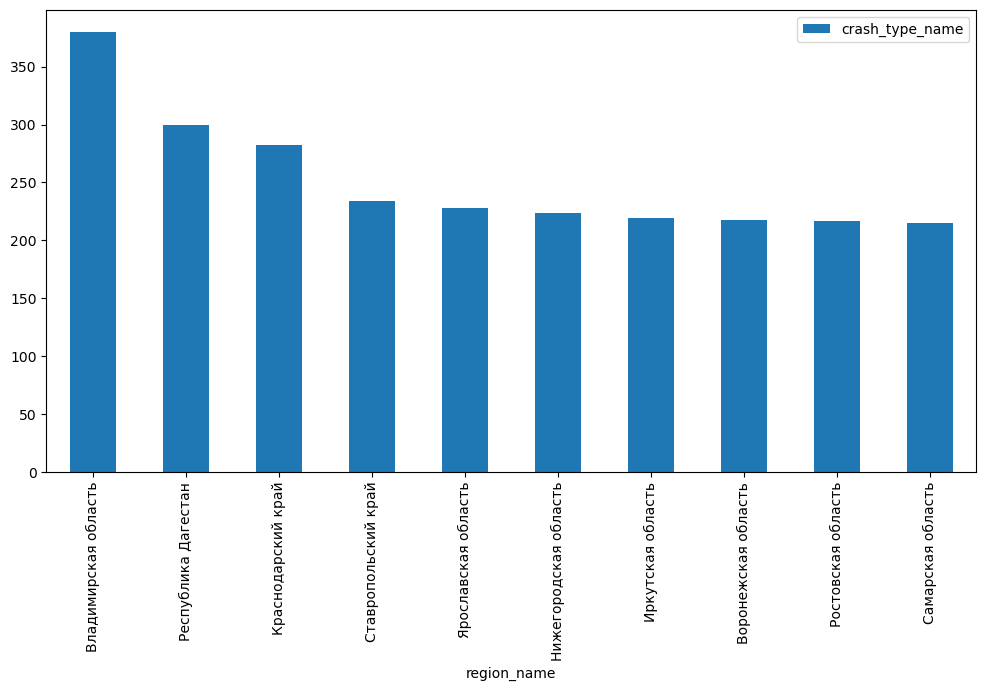

In [47]:
road_region_data.head(10).plot(kind = 'bar',
                      x = 'region_name',
                      y = 'crash_type_name',
                     figsize = (12,6))



Наибольшая концентрация аварийности наблюдается в регионах Центральной России и Северного Кавказа. Также эти регионы фиксируют наибольшее показатели тяжести ДТП: количество пострадавших и погибших.

Такие показатели могут быть причинами высокая интенсивности движения в центральных регионах, сложных горных участков на Кавказе, туристические потоки. 

<b> 9. Распределения числа ДТП по регионам для каждой дороги.

                                crash_type_name
region_name                                    
Владимирская область                        380
Нижегородская область                       224
Республика Татарстан                        180
Московская область                          140
Удмуртская Республика                       122
Чувашская Республика — Чувашия              110
Пермский край                                50
Республика Башкортостан                      43
Ивановская область                           28


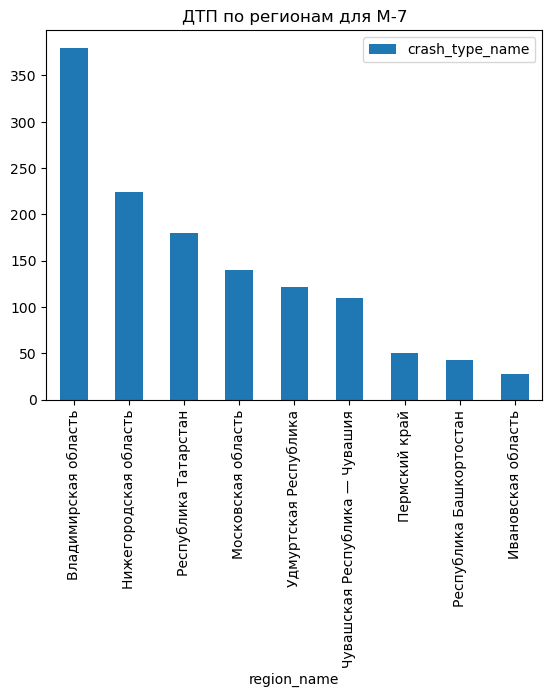

                                     crash_type_name
region_name                                         
Республика Дагестан                              300
Ставропольский край                              234
Краснодарский край                               141
Кабардино-Балкарская Республика                   97
Республика Северная Осетия — Алания               65
Карачаево-Черкесская Республика                   37
Республика Ингушетия                              35
Чеченская Республика                              28
Республика Адыгея                                  6


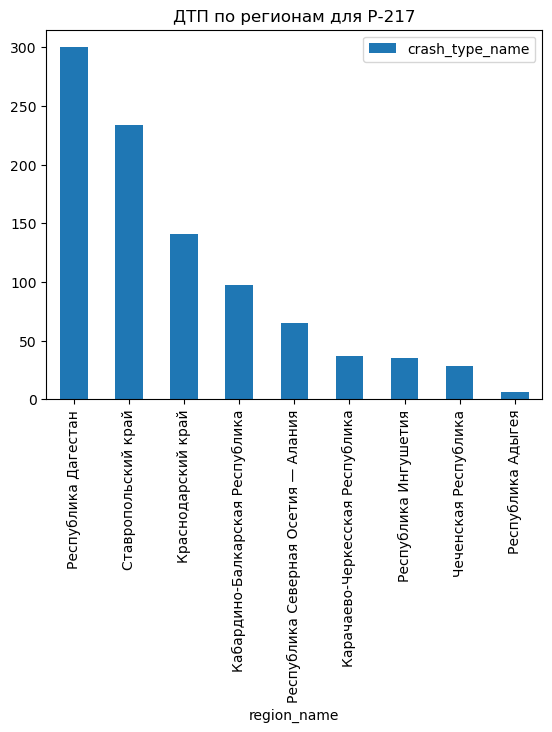

                     crash_type_name
region_name                         
Краснодарский край               282
Воронежская область              218
Ростовская область               217
Тульская область                 121
Липецкая область                  97
Московская область                69
Республика Адыгея                 31


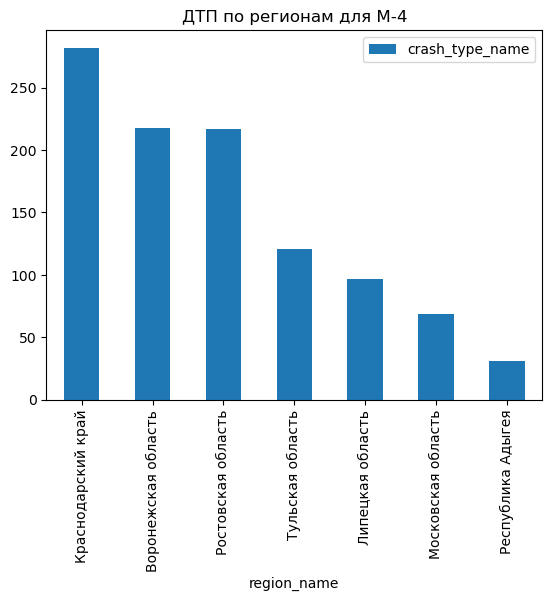

                       crash_type_name
region_name                           
Ярославская область                228
Архангельская область              116
Московская область                  63
Вологодская область                 46
Владимирская область                 6
Костромская область                  4


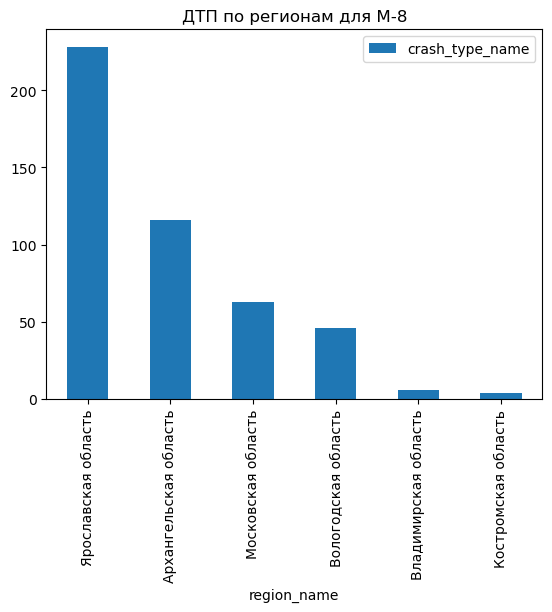

                       crash_type_name
region_name                           
Иркутская область                  219
Красноярский край                  210
Кемеровская область                125
Новосибирская область               37
Томская область                      7


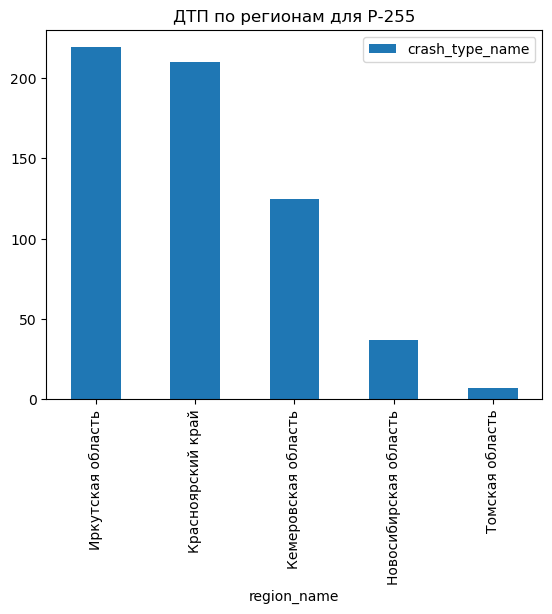

                         crash_type_name
region_name                             
Самарская область                    215
Пензенская область                   176
Рязанская область                    171
Челябинская область                  167
Республика Башкортостан              128
Республика Мордовия                   88
Оренбургская область                  87
Московская область                    66
Ульяновская область                   55
Свердловская область                  19


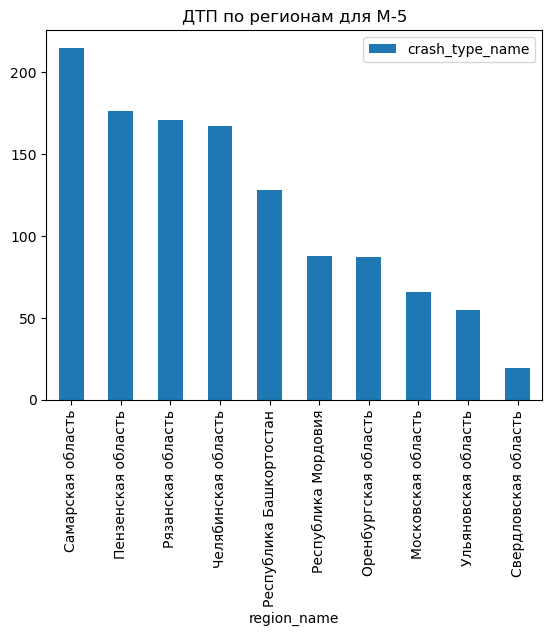

                      crash_type_name
region_name                          
Тульская область                  194
Московская область                 86
Курская область                    85
Орловская область                  77
Белгородская область               49
Москва                              1


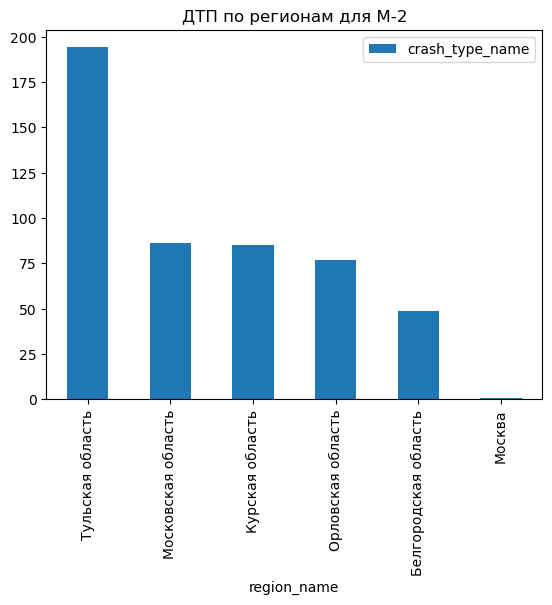

                       crash_type_name
region_name                           
Тверская область                   135
Московская область                 105
Новгородская область               104
Ленинградская область              102
Москва                              68


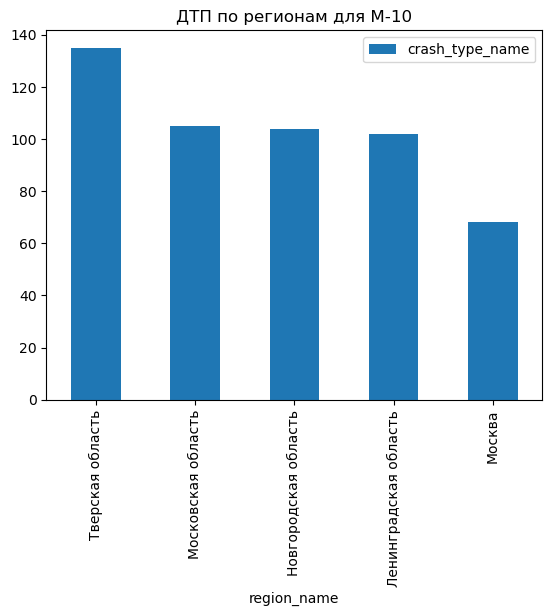

                       crash_type_name
region_name                           
Курганская область                  98
Новосибирская область               82
Омская область                      52
Тюменская область                   47
Челябинская область                 19


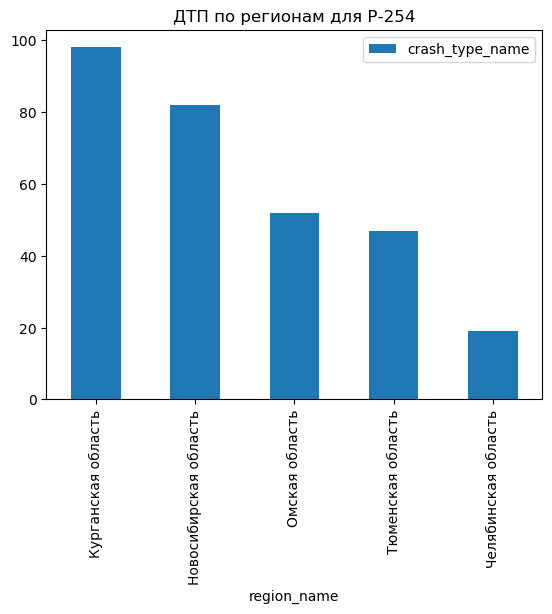

                       crash_type_name
region_name                           
Тамбовская область                  95
Астраханская область                86
Волгоградская область               80
Рязанская область                   70
Республика Калмыкия                 49
Саратовская область                 48
Московская область                  22
Воронежская область                 21
Тульская область                     6


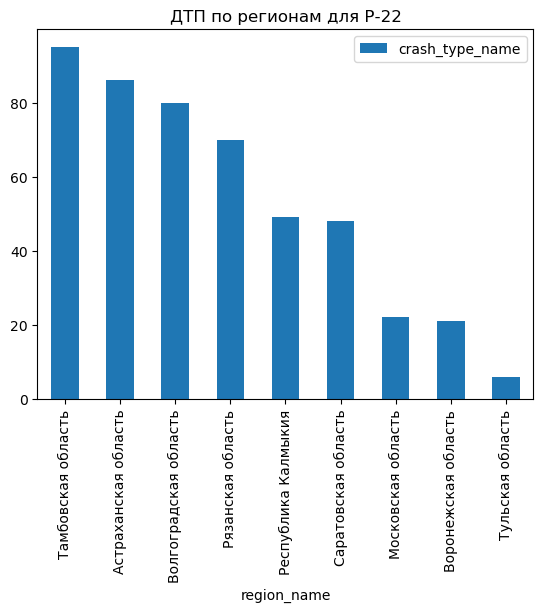

In [48]:
code = road_region_data['road_code'].unique().tolist()
for road_code in code:
    top_region_pivot = data.query('road_code == @road_code').pivot_table(index = 'region_name',
                                                                         values = 'crash_type_name',
                                                                         aggfunc = 'count').sort_values(by = 'crash_type_name', ascending = False).head(10)
    top_region_pivot.plot(kind = 'bar', y = 'crash_type_name', title = f'ДТП по регионам для {road_code}')
    print(top_region_pivot)
    plt.show()

Для объяснения причин аварийности на дорогах можно опираться на специализацию регионов и их географическую расположенность. Так, дорога М-7 проходит через регионы - Владимирская область, который является ключевым транзитным участком между Москвой и востоком, Нижегородская область, Республика Татарстан - промышленные регионы, с подъездами к крупным городам. 

На дороге Р-217 оснвными аварийными участками стали Республика Дагестан, Ставропольчкий край, Краснодарский край. Основынми причинами может стать горный рельеф: погодных условий, ограниченная видимость, туристический потоки к курортам Кавказа, частые сельскохозяйственные перевозки.

На трассе М-4 резко выделяются Краснодарский ркай, Воронежская область, Ростовская область. Данные дороги - важная артерия для сообщения с южными регионами. 

Трасса М-8 соединят Москву с северными регионами, а также Архангельском. Высокая аварийность на данных участках могут происходить из-за погодных условий, дальних перевозок, плотности населенных пунктов и высокой интенсивности движения.

Р-255 - одна из важнейших транссибирских магистралей, проходит через регионы Западной и Восточной Сибири, соединяя промышленные центры. Сложный рельеф, разнообразие коиматических зон, а также близость к Байкалу с высоким турестическим тррафиком влияют на количество ДТП.

Дорого М-5 одна из самых больших по количеству субъектов (11), соединяет Москву с Уралом и Сибирью. Причины аварийности все такие же - промышленные регионы, высокая интенсивность движения. Низкая аварийность наблюдается в начале трассы - Московской области, наиболее аварйиные Центральные регионы.

Авайрийность на трассе М-2 может быть обусловлена соединением с туристическими регионами, выоской интенсивностью движения, грузовыми перевозками, её снижение наблюдается по мере отдаления от Москвы.

Трасса М-10 соединяет наиболее плотно населенные регионы - Москву и санкт-Петербург и проходит через Москлвскую, Тверскую, Новогородскую, Ленинградскую области, обеспечивая масштабный грузопоток, прздничные поездки.

Трасса Р-254 также соединяет промышленные центры Урала и Сибири. Причинами может стать - активное движение фур, сложные дорожные условия зимой, огромные расстояния.

Высокая аварийность на трассе Р-22 растет в южных регионах - это загруженные направления к морю. Резко возрастает аварийность в Тамбовской, Астраханской и Волгоградской области.